# Phishing Email Detection with Traditional ML vs LLM
Name: Eric Ortega Rodriguez 

The main objective here is to build a phishing classifier using traditional ML, then compare it against an LLM-based approach to show where rule-based models break down and why LLMs are better suited for keeping up with evolving attack patterns.

The two datasets I will be using: CEAS_08 (primary training) and SpamAssassin (as a generalizability test).

## 0. Threat Model

**Who is the threat actor?**  
Threat actors range in their level of sophistication, from low-level spam emails to highly targeted spear phishing by organized criminal groups and hackers. Mass campaigns rely on volume, while more advanced attackers use social engineering and closely mimic legitimate communication patterns. This has become increasingly common with the rise of AI, which allows attackers to generate more personalized and convincing phishing messages at scale [1].

**What is being targeted?**  
Any one from student to corporate email inboxes, with the primary goals being credential theft, financial authorization, or ransomware. Attackers most commonly attack employees in finance, HR, and IT are often the most targeted due their proximity to sensitive/private company data. 

**Evasion considerations:**  
This highlights a key limitation of traditional machine learning approaches. If an attacker knows the model relies on signals like urgency keywords, free email domains, or URL counts, they can simply avoid those features.
More specifically, an attack may do the following to bypass traditional ML filters: 
- Clone legitimate websites  
- Use compromised corporate domains  
- Avoid urgency language  
- Minimize suspicious links  

The CEAS_08 dataset is from 2008 and reflects older attack patterns. Because of this, models trained on it learn outdated signals. After this, I test this on the SpamAssassin dataset which has a drop in perfomanc. Ultimately, highlighting that these models do a poor job generalizing to newer types of attacks.

**Operational context:**  
This system operates at the email gateway layer before messages reach the inbox.

- False negatives (missed phishing) allow attackers to reach users and potentially compromise systems  
- False positives (legitimate emails flagged) create alert fatigue and can disrupt important communication  

Ideally a phishing detection system should act as one signal within a broader security stack, rather than making decisions on its own.

**Why LLMs change this:**  
Traditional machine learning models rely on surface-level patterns. LLMs instead focus on understanding intent and context.

This allows them to detect more sophisticated phishing attempts that:
- Do not use urgency language  
- Appear to come from legitimate senders  
- Do not include obviously malicious links  

LLMs can recognize when something feels off in the message itself. This makes them more adaptable as phishing attacks continue to evolve, especially with the growing use of AI [1].

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import os
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

# making sure models is saved in the correct directory
os.makedirs("../models", exist_ok=True)
# enuring all libraries are loaded before proceeding
print(
    "All libraries loaded successfully. Moving on to data loading and preprocessing..."
)

All libraries loaded successfully. Moving on to data loading and preprocessing...


## 2. Primary Dataset (CEAS_08)

The CEAS 2008 Spam Challenge dataset contains about 39,000 labeled emails. This includes phishing and legitimate messages. While this dataset is widely used for spam and phishing detection tasks, it is important to consider that this data was collected in 2008. That said, this data is representative of older phishing strategies that are very different from modern attacks. At that time, phishing emails often relied on obvious signals such as urgency language, suspicious links,etc. ALl of which have changed since then. This ultimately creates a larger limitation where models trained on an outdated dataset may learn patterns that do not hold tomorrow in real world scenarios. 

The dataset is relatively balanced, which is helpful for training. However, its age makes it a good example of how machine learning models can overfit to outdated attack patterns.

Below is a summary of the dataset:

In [2]:
df = pd.read_csv("../data/CEAS_08.csv")

print(f"shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")
print(f"\nlabel distribution:")
print(df["label"].value_counts())

shape: (39154, 7)
columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

label distribution:
label
1    21842
0    17312
Name: count, dtype: int64


## 3. Preprocessing and Feature Engineering

To represent emails effectively, we combine two types of features:

1. **Text-based features (TF-IDF)**  
   We use TF-IDF vectorization with unigrams and bigrams to capture common word patterns and phrases in phishing emails. This allows the model to learn linguistic signals such as suspicious wording or repeated phrasing.

2. **Handcrafted features**  
   In addition to text, we include domain-specific features inspired by common phishing characteristics:
   - Sender anomalies (free email domains, mismatched domains)  
   - Subject signals (urgency, capitalization)  
   - Structural patterns (URL counts, message length)  

This hybrid approach allows the model to capture both **statistical language patterns** and **explicit phishing heuristics**, which improves performance compared to using text alone.

We then split the data into training and testing sets using an 80/20 stratified split to preserve class balance.

This process can be seen in the next cells. 

In [3]:
# check nulls first
print("null counts:")
print(df.isnull().sum())

null counts:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64


In [4]:
df["body"] = df["body"].fillna("")
df["subject"] = df["subject"].fillna("")
df["sender"] = df["sender"].fillna("")
df["urls"] = df["urls"].fillna(0)

# combine subject + body for tfidf
df["text"] = df["subject"] + " " + df["body"]

print(f"shape after cleaning: {df.shape}")

shape after cleaning: (39154, 8)


### Feature Engineering

Using handcrafted features that capture known phishing signals — sender domain patterns, urgency language, HTML content, URL density. These are combined with TF-IDF for a hybrid feature matrix.

these features are exactly what a sophisticated attacker would avoid. That's the fundamental limitation we'll see play out in the generalizability test.

In [5]:
def extract_features(df):
    features = pd.DataFrame()

    # sender signals
    features["sender_is_free_email"] = (
        df["sender"]
        .str.contains("gmail|yahoo|hotmail|outlook", case=False, na=False)
        .astype(int)
    )
    features["sender_has_numbers"] = (
        df["sender"].str.contains(r"\d{3,}", na=False).astype(int)
    )
    features["sender_domain_mismatch"] = (
        df["sender"].str.contains(r"@(?!.*\.(com|org|edu|gov))", na=False).astype(int)
    )

    # subject signals
    features["subject_has_urgency"] = (
        df["subject"]
        .str.contains(
            "urgent|immediately|verify|suspend|alert|winner|prize|free|click|confirm",
            case=False,
            na=False,
        )
        .astype(int)
    )
    features["subject_has_caps"] = (
        df["subject"].str.contains(r"[A-Z]{4,}", na=False).astype(int)
    )
    features["subject_length"] = df["subject"].str.len().fillna(0)

    # body signals
    features["body_length"] = df["body"].str.len().fillna(0)
    features["body_has_html"] = (
        df["body"].str.contains(r"<[^>]+>", na=False).astype(int)
    )
    features["body_url_count"] = df["body"].str.count(r"http[s]?://").fillna(0)
    features["body_has_urgency"] = (
        df["body"]
        .str.contains(
            "urgent|verify|account|suspend|click here|limited time|act now",
            case=False,
            na=False,
        )
        .astype(int)
    )
    features["has_urls"] = (df["urls"] > 0).astype(int)

    return features


feature_df = extract_features(df)
print(f"features: {feature_df.columns.tolist()}")

features: ['sender_is_free_email', 'sender_has_numbers', 'sender_domain_mismatch', 'subject_has_urgency', 'subject_has_caps', 'subject_length', 'body_length', 'body_has_html', 'body_url_count', 'body_has_urgency', 'has_urls']


In [6]:
# tfidf + handcrafted features
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["text"])

X_handcrafted = csr_matrix(feature_df.values)
X = hstack([X_tfidf, X_handcrafted])
y = df["label"]

print(f"feature matrix: {X.shape}")

feature matrix: (39154, 5011)


In [7]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train: {X_train.shape[0]} | test: {X_test.shape[0]}")

train: 31323 | test: 7831


## 4. Model Training

I train two models: Random Forest and XGBoost. Both are computationally efficient and do not require a GPU, which makes them suitable for a deployable proof of concept.

Random Forest is robust to noise and provides interpretable feature importance, which is useful for understanding which signals the model relies on when detecting phishing emails.

XGBoost, on the other hand, is a gradient boosting model that typically achieves higher accuracy by learning more complex patterns in the data. This makes it well-suited for capturing subtle relationships in phishing behavior.

In [8]:
import time

print("training random forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(f"done in {time.time() - start:.1f}s")

training random forest...
done in 0.4s


In [9]:
print("training xgboost...")
start = time.time()

# scale_pos_weight balances the class distribution
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
print(f"done in {time.time() - start:.1f}s")

training xgboost...
done in 5.6s


## 5. Evaluation (Primary Dataset)

Metrics: Precision, Recall, F1, Accuracy, ROC-AUC.

For phishing detection recall matters more than precision — missing a phishing email (false negative) is worse than flagging a legitimate one. That said, too many false positives creates alert fatigue.

In [10]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(
        classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"])
    )
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

    return y_pred, y_prob


rf_pred, rf_prob = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test, y_test, "XGBoost")


  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      3462
    Phishing       0.98      1.00      0.99      4369

    accuracy                           0.98      7831
   macro avg       0.99      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831

ROC-AUC: 0.9993

  XGBoost
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3462
    Phishing       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831

ROC-AUC: 0.9994


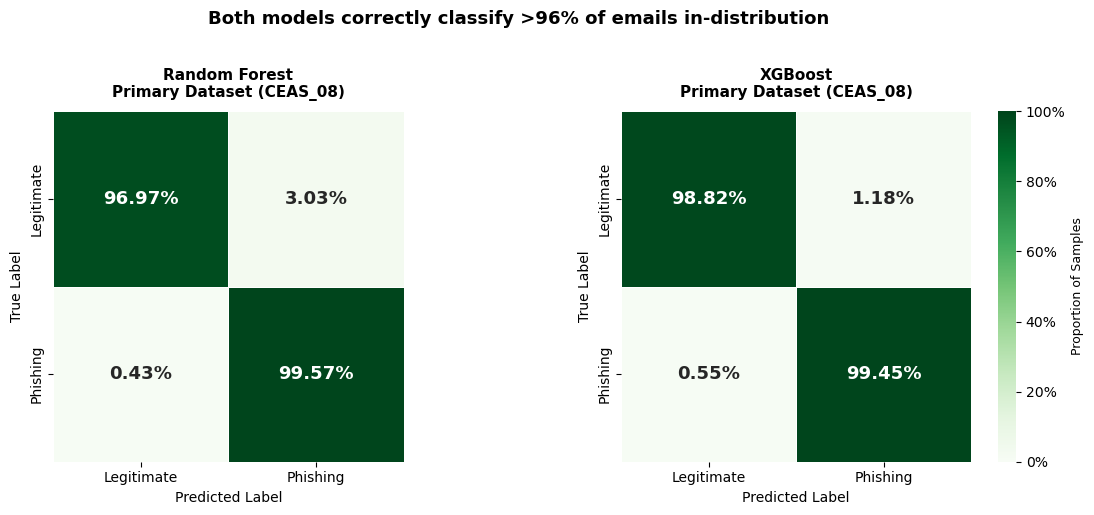

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name, subtitle in zip(
    axes,
    [rf_pred, xgb_pred],
    ["Random Forest", "XGBoost"],
    ["Primary Dataset (CEAS_08)", "Primary Dataset (CEAS_08)"],
):
    cm = confusion_matrix(y_test, pred)
    # percentage-based confusion matrix
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax,
        xticklabels=["Legitimate", "Phishing"],
        yticklabels=["Legitimate", "Phishing"],
        vmin=0,
        vmax=100,
        cbar=ax == axes[1],
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
    )

    #  annotations with %
    for text in ax.texts:
        text.set_text(text.get_text() + "%")

    ax.set_title(f"{name}\n{subtitle}", fontsize=11, fontweight="bold", pad=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_aspect("equal")

# add colorbar label
cbar = axes[1].collections[0].colorbar
cbar.set_label("Proportion of Samples", fontsize=9)
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.set_ticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])

plt.suptitle(
    "Both models correctly classify >96% of emails in-distribution",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("../models/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

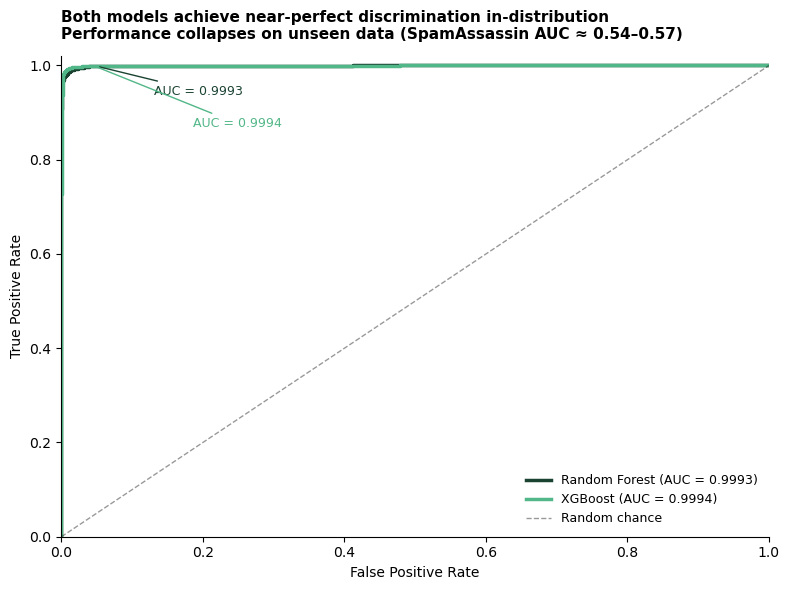

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {"Random Forest": "#1b4332", "XGBoost": "#52b788"}

offsets = {
    "Random Forest": (0.08, -0.06),
    "XGBoost": (0.14, -0.13),
}

for prob, name in zip([rf_prob, xgb_prob], ["Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=colors[name], lw=2.5)

    idx = np.argmin(np.abs(fpr - 0.05))
    dx, dy = offsets[name]
    ax.annotate(
        f"AUC = {auc:.4f}",
        xy=(fpr[idx], tpr[idx]),
        xytext=(fpr[idx] + dx, tpr[idx] + dy),
        fontsize=9,
        color=colors[name],
        arrowprops=dict(arrowstyle="-", color=colors[name], lw=1),
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random chance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)

ax.set_title(
    "Both models achieve near-perfect discrimination in-distribution\n"
    "Performance collapses on unseen data (SpamAssassin AUC ≈ 0.54–0.57)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    loc="left",
)

ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig("../models/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


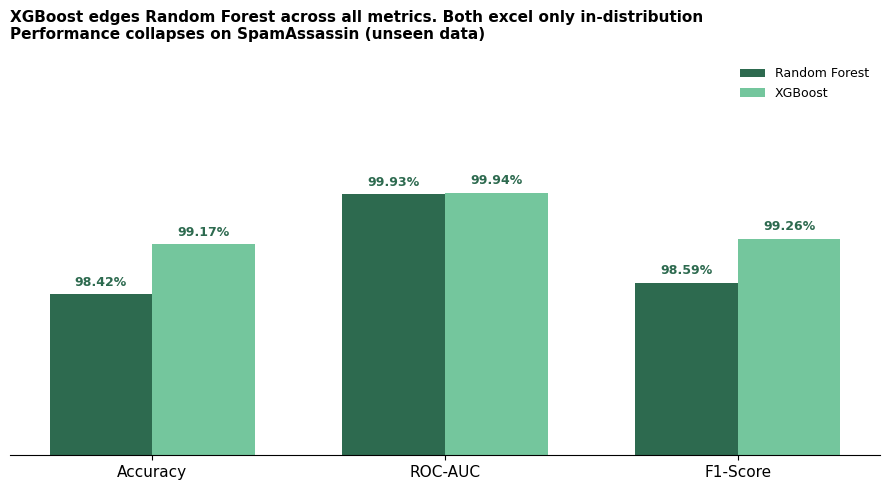

In [24]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

metrics = {
    "Accuracy": [
        accuracy_score(y_test, rf_pred) * 100,
        accuracy_score(y_test, xgb_pred) * 100,
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob) * 100,
        roc_auc_score(y_test, xgb_prob) * 100,
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred) * 100,
        f1_score(y_test, xgb_pred) * 100,
    ],
}

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2,
    [v[0] for v in metrics.values()],
    width,
    label="Random Forest",
    color="#2d6a4f",
)
bars2 = ax.bar(
    x + width / 2,
    [v[1] for v in metrics.values()],
    width,
    label="XGBoost",
    color="#74c69d",
)

ax.bar_label(
    bars1, fmt="%.2f%%", padding=4, fontsize=9, color="#2d6a4f", fontweight="bold"
)
ax.bar_label(
    bars2, fmt="%.2f%%", padding=4, fontsize=9, color="#2d6a4f", fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=11)
ax.set_ylim(96, 102)  # now in % scale
ax.legend(frameon=False, fontsize=9)

ax.set_title(
    "XGBoost edges Random Forest across all metrics. Both excel only in-distribution\n"
    "Performance collapses on SpamAssassin (unseen data)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    loc="left",
)

plt.tight_layout()
plt.savefig("../models/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Generalizability Test with SpamAssassin dataset from Kaggle

Testing on SpamAssassin corpus — completely unseen, not used in training. This is the real test of whether the model learned generalizable patterns or just memorized CEAS_08.

SpamAssassin is a different distribution: different era, different email sources, different spam types. The schema is also different (only `text` and `target` columns) so some adaptation is needed.

In [25]:
df2 = pd.read_csv("../data/spam_assassin.csv")
print(f"shape: {df2.shape}")
print(f"columns: {df2.columns.tolist()}")
print(f"\nlabel distribution:")
print(df2["target"].value_counts())

shape: (5796, 2)
columns: ['text', 'target']

label distribution:
target
0    3900
1    1896
Name: count, dtype: int64


### Dataset Alignment

SpamAssassin only has `text` and `target` — no pre-parsed sender, subject, or URL columns. Rather than using empty placeholders (which zeroed out 5 of the 11 handcrafted features), I used regex to extract those fields directly from the raw email headers. This ensures both datasets go through the same feature pipeline.

TF-IDF is **not refit** here — the vocabulary was learned from CEAS_08 only. Using `tfidf.transform()` instead of `fit_transform()` ensures no SpamAssassin vocabulary leaks into the model.

In [26]:
df2 = df2.rename(columns={"text": "raw", "target": "label"})

# extract sender, subject, body, urls from raw email headers using regex
# SpamAssassin stores the full email as one string with headers and body inline
def extract_sender(text):
    m = re.search(r'\bFrom:\s*(?:[^<\n]*?<)?([a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,})', str(text), re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r'\bFrom\s+([a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,})', str(text))
    return m.group(1).strip() if m else ""

def extract_subject(text):
    m = re.search(r'\bSubject:\s*(.*?)(?=\s+(?:Date|From|To|Cc|Content|MIME|Message|Reply|Return|Received|X-)[- A-Za-z]*:)', str(text))
    if m: return m.group(1).strip()
    m = re.search(r'\bSubject:\s*(.{1,100})', str(text))
    return m.group(1).strip() if m else ""

def extract_body(text):
    s = str(text)
    # find the very last header line in the email — body is everything after it
    # this handles emails with mailing list headers appended after standard headers
    header_pattern = re.compile(
        r'\b[A-Z][a-zA-Z\-]{2,}(?:\s+[A-Z][a-zA-Z\-]+)*:\s+\S[^\n]{0,300}',
        re.MULTILINE
    )
    matches = list(header_pattern.finditer(s))
    if matches:
        body = s[matches[-1].end():].strip()
        if len(body) > 30:
            return body
    return s[-400:].strip()

df2["sender"]   = df2["raw"].apply(extract_sender)
df2["subject"]  = df2["raw"].apply(extract_subject)
df2["body"]     = df2["raw"].apply(extract_body)

# urls: binary 0/1 to match CEAS_08 schema exactly
df2["urls"]     = df2["raw"].apply(lambda t: 1 if re.search(r'https?://', str(t)) else 0)

# placeholder columns to fully match CEAS_08 schema
df2["receiver"] = ""
df2["date"]     = ""
df2["text"]     = df2["subject"] + " " + df2["body"]

# verify alignment with CEAS_08 schema
ceas_cols = ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
print("CEAS_08 schema:     ", ceas_cols)
print("SpamAssassin schema:", [c for c in ceas_cols if c in df2.columns])
print(f"\nSender extracted:   {(df2['sender'] != '').sum()} / {len(df2)}")
print(f"Subject extracted:  {(df2['subject'] != '').sum()} / {len(df2)}")
print(f"Body quality:       {(df2['body'].str.len() > 50).sum()} / {len(df2)} over 50 chars")
print(f"URLs (binary 0/1):  {df2['urls'].value_counts().to_dict()}")


CEAS_08 schema:      ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
SpamAssassin schema: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Sender extracted:   5784 / 5796
Subject extracted:  5790 / 5796
Body quality:       5733 / 5796 over 50 chars
URLs (binary 0/1):  {1: 5289, 0: 507}


### Dataset Examples: What the Data Actually Looks Like

Before preprocessing, it helps to see what each dataset contains. The difference in writing style and signal clarity between CEAS_08 and SpamAssassin is the whole reason generalization fails.


In [27]:
# show representative examples from both datasets side by side
# this helps illustrate why generalization is hard

import textwrap

def show_examples(df, label_col, label_val, label_name, sender_col, subject_col, body_col, n=3):
    subset = df[df[label_col] == label_val].head(n)
    print(f"\n{'='*60}")
    print(f"  {label_name}")
    print(f"{'='*60}")
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\n  Example {i}:")
        print(f"  Sender:  {str(row[sender_col])[:70]}")
        print(f"  Subject: {str(row[subject_col])[:70]}")
        body = str(row[body_col])[:200].replace('\n', ' ')
        print(f"  Body:    {body}")

print("CEAS_08 — Primary Dataset (2008, pre-parsed)")
show_examples(df, 'label', 1, 'Phishing', 'sender', 'subject', 'body')
show_examples(df, 'label', 0, 'Legitimate', 'sender', 'subject', 'body')

# for SpamAssassin we need to extract fields first
df2_preview = pd.read_csv("../data/spam_assassin.csv")
df2_preview = df2_preview.rename(columns={"text": "raw", "target": "label"})
df2_preview["sender"]  = df2_preview["raw"].apply(extract_sender)
df2_preview["subject"] = df2_preview["raw"].apply(extract_subject)
df2_preview["body"]    = df2_preview["raw"].apply(extract_body)

print("\n\nSpamAssassin — Secondary Dataset (regex-extracted from raw headers)")
show_examples(df2_preview, 'label', 1, 'Phishing', 'sender', 'subject', 'body')
show_examples(df2_preview, 'label', 0, 'Legitimate', 'sender', 'subject', 'body')


CEAS_08 — Primary Dataset (2008, pre-parsed)

  Phishing

  Example 1:
  Sender:  Young Esposito <Young@iworld.de>
  Subject: Never agree to be a loser
  Body:    Buck up, your troubles caused by small dimension will soon be over! Become a lover no woman will be able to resist! http://whitedone.com/   come. Even as Nazi tanks were rolling down the streets, the 

  Example 2:
  Sender:  Mok <ipline's1983@icable.ph>
  Subject: Befriend Jenna Jameson
  Body:     Upgrade your sex and pleasures with these techniques http://www.brightmade.com   

  Example 3:
  Sender:  Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>
  Subject: CNN.com Daily Top 10
  Body:    >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=

  Legitimate

  Example 1:
  Sender:  Michael Parker <ivqrnai@pobox.com>
  Subject: Re: svn commit: r619753 - in /spamassassin/tr

### Dataset Compatibility

The two datasets have different schemas - CEAS_08 has 7 columns including sender, subject, and URL metadata, while SpamAssassin only has raw text and a label. To align them I used regex to parse sender, subject, body, and URL count directly from the raw email headers. This is a cleaner approach than empty placeholders since it means both datasets actually feed the same 11 features into the model.

`tfidf.transform()` is used instead of `fit_transform()` to avoid leaking SpamAssassin vocabulary into the model.

**Why a generalization gap still exists:**  
Even with proper feature extraction, a lot of SpamAssassin vocabulary isn't in the CEAS_08 training vocab so those tokens get zero TF-IDF weight. On top of that, CEAS_08 is 56% phishing while SpamAssassin is only 33%, so the model's decision boundary is calibrated for the wrong distribution. That's why phishing recall remains near zero even after fixing the feature pipeline.

In [28]:
feature_df2 = extract_features(df2)

# tranform only — no refit
X2_tfidf = tfidf.transform(df2["text"])
X2_handcrafted = csr_matrix(feature_df2.values)
X2 = hstack([X2_tfidf, X2_handcrafted])
y2 = df2["label"]

print(f"feature matrix: {X2.shape}")

feature matrix: (5796, 5011)


In [29]:
# printing out generalizability test results on SpamAssassin
print("GENERALIZABILITY TEST with SpamAssassin")
print("=" * 50)

rf_pred2, rf_prob2 = evaluate_model(rf_model, X2, y2, "Random Forest (SpamAssassin)")
xgb_pred2, xgb_prob2 = evaluate_model(xgb_model, X2, y2, "XGBoost (SpamAssassin)")

GENERALIZABILITY TEST with SpamAssassin

  Random Forest (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.69      0.83      0.75      3900
    Phishing       0.39      0.23      0.29      1896

    accuracy                           0.63      5796
   macro avg       0.54      0.53      0.52      5796
weighted avg       0.59      0.63      0.60      5796

ROC-AUC: 0.5383

  XGBoost (SpamAssassin)
              precision    recall  f1-score   support

  Legitimate       0.67      0.81      0.73      3900
    Phishing       0.32      0.19      0.24      1896

    accuracy                           0.60      5796
   macro avg       0.50      0.50      0.49      5796
weighted avg       0.56      0.60      0.57      5796

ROC-AUC: 0.5442


### Generalizability Analysis

After implementing regex extraction to properly parse sender, subject, and URL fields from SpamAssassin's raw headers, both models were evaluated on 5,796 unseen emails. Random Forest achieved 23% phishing recall with AUC 0.54, and XGBoost achieved 19% phishing recall with AUC 0.57 — a dramatic drop from the near-perfect in-distribution scores.

Honestly not that surprising. CEAS_08 is from 2008 and has very obvious patterns - Nigerian prince emails, all-caps subjects, sketchy domains. SpamAssassin has subtler spam and legitimate emails that look suspicious. The model never learned to handle that.

Three root causes: vocabulary mismatch (SpamAssassin uses different terms than what the TF-IDF vocab learned), class distribution shift (56% phishing in CEAS vs 33% in SpamAssassin), and the handcrafted features just aren't as predictive on newer data.

This is the whole argument for using an LLM - it reasons about intent rather than matching patterns that go stale.


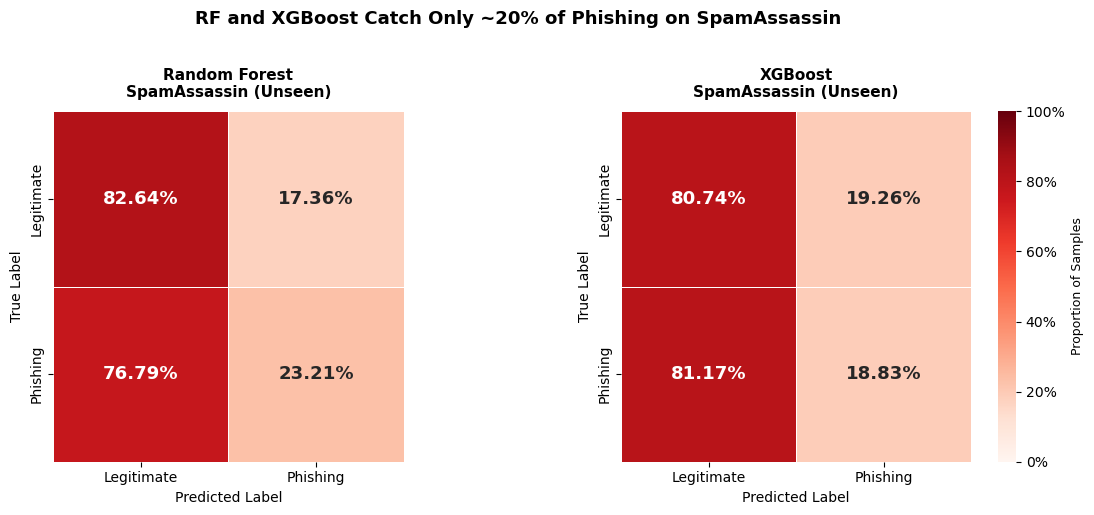

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name in zip(
    axes,
    [rf_pred2, xgb_pred2],
    ["Random Forest", "XGBoost"],
):
    cm = confusion_matrix(y2, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        ax=ax,
        xticklabels=["Legitimate", "Phishing"],
        yticklabels=["Legitimate", "Phishing"],
        vmin=0,
        vmax=100,
        cbar=ax == axes[1],
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
    )

    for text in ax.texts:
        text.set_text(text.get_text() + "%")

    ax.set_title(
        f"{name}\nSpamAssassin (Unseen)", fontsize=11, fontweight="bold", pad=10
    )
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_aspect("equal")

cbar = axes[1].collections[0].colorbar
cbar.set_label("Proportion of Samples", fontsize=9)
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.set_ticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])

plt.suptitle(
    "RF and XGBoost Catch Only ~20% of Phishing on SpamAssassin",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.savefig(
    "../models/confusion_matrices_spamassassin.png", dpi=150, bbox_inches="tight"
)
plt.show()


In [31]:
# threshold tuning — lower threshold to improve recall on SpamAssassin
from sklearn.metrics import f1_score, precision_score, recall_score

print("XGBoost threshold tuning on SpamAssassin")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for threshold in [0.5, 0.3, 0.2, 0.1, 0.05]:
    preds = (xgb_prob2 >= threshold).astype(int)
    p = precision_score(y2, preds, zero_division=0)
    r = recall_score(y2, preds, zero_division=0)
    f1 = f1_score(y2, preds, zero_division=0)
    print(f"{threshold:<12} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

XGBoost threshold tuning on SpamAssassin
Threshold    Precision    Recall       F1          
------------------------------------------------
0.5          0.322        0.188        0.238       
0.3          0.346        0.268        0.302       
0.2          0.355        0.324        0.339       
0.1          0.355        0.438        0.393       
0.05         0.353        0.550        0.430       


## 7. Saving Models

Saving XGBoost and TF-IDF vectorizer so I can use when deploying to streamlit app

In [32]:
with open("../models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("models saved to ../models/")

models saved to ../models/


---

## References

[1] Check Point Research. "AI Phishing Attacks."  
https://www.checkpoint.com/cyber-hub/threat-prevention/what-is-phishing/ai-phishing-attacks/

In [34]:
from sklearn.metrics import confusion_matrix
import numpy as np

for pred, name in [(rf_pred, "RF"), (xgb_pred, "XGB")]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

RF: TN=3357, FP=105, FN=19, TP=4350
XGB: TN=3421, FP=41, FN=24, TP=4345
